In [ ]:
#  Inventory Forecasting and Recommendation System
## For a Multi-Bar Hotel Chain
This notebook presents a complete solution to forecast item-level demand and recommend weekly inventory levels (par levels) to prevent stockouts and reduce overstocking across multiple bars.


In [ ]:
#libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore")

# Load the Excel file
file_path = "Consumption Dataset.xlsx"  # Adjust path as needed
df = pd.read_excel(file_path, sheet_name='Dataset')
df.head()


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [ ]:
##  Data Cleaning & Weekly Aggregation
We convert the 'Date Time Served' into weekly format and aggregate consumption data per bar and brand.

In [2]:
# Convert DateTime column
df['Date'] = pd.to_datetime(df['Date Time Served']).dt.date
df['Week'] = pd.to_datetime(df['Date']).dt.to_period('W').apply(lambda r: r.start_time)

# Weekly aggregation by Bar and Brand
weekly_df = df.groupby(['Week', 'Bar Name', 'Brand Name'])['Consumed (ml)'].sum().reset_index()
weekly_df.head()


,Week,Bar Name,Brand Name,Consumed (ml)
0,2022-12-26,Anderson's Bar,Bacardi,0.0
1,2022-12-26,Anderson's Bar,Jim Beam,0.0
2,2022-12-26,Anderson's Bar,Miller,0.0
3,2022-12-26,Anderson's Bar,Sutter Home,0.0
4,2022-12-26,Brown's Bar,Captain Morgan,0.0


In [9]:
##  Exploratory Data Analysis
Visualizing the most consumed brands across all bars.


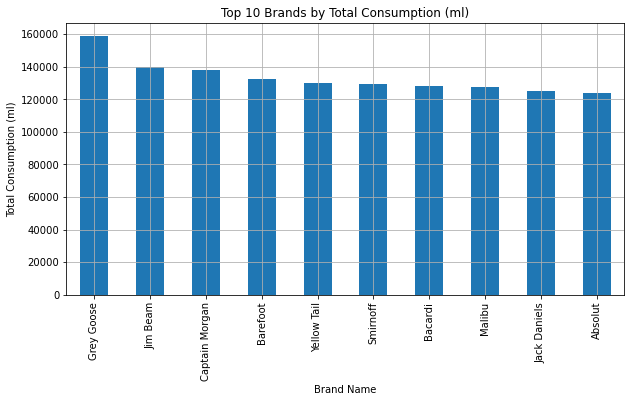

In [3]:
# Top 10 most consumed brands
top_brands = weekly_df.groupby('Brand Name')['Consumed (ml)'].sum().sort_values(ascending=False).head(10)
top_brands.plot(kind='bar', title='Top 10 Brands by Total Consumption (ml)', figsize=(10,5))
plt.ylabel('Total Consumption (ml)')
plt.grid(True)
plt.show()


In [ ]:
## Forecasting Example
Forecast demand for "Captain Morgan" at "Smith's Bar" using Exponential Smoothing.


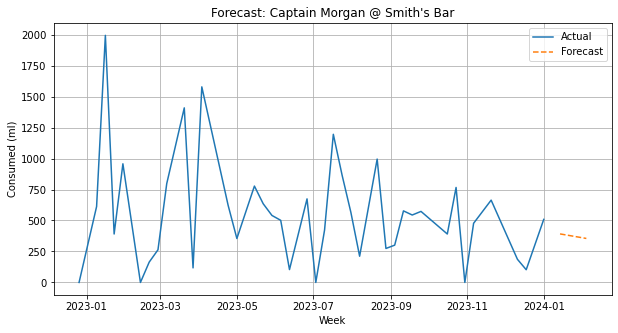

In [4]:
# Example: Forecasting for Captain Morgan at Smith's Bar
sample = weekly_df[(weekly_df['Bar Name'] == "Smith's Bar") & 
                   (weekly_df['Brand Name'] == "Captain Morgan")]

sample = sample.sort_values('Week').reset_index(drop=True)
ts = sample['Consumed (ml)']

# Fit Exponential Smoothing
model = ExponentialSmoothing(ts, trend='add', seasonal=None)
fit = model.fit()
forecast = fit.forecast(4)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(sample['Week'], ts, label='Actual')
future_weeks = pd.date_range(start=sample['Week'].max(), periods=5, freq='W')[1:]
plt.plot(future_weeks, forecast, label='Forecast', linestyle='--')
plt.title("Forecast: Captain Morgan @ Smith's Bar")
plt.xlabel('Week')
plt.ylabel('Consumed (ml)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
## Par Level Recommendation Logic
Par level is calculated as:  
\[
\text{Par Level} = \text{Average Weekly Demand} + 1.5 \times \text{Standard Deviation}
\]


In [5]:
# Calculate recommended par level (average + 1.5 * std dev of weekly consumption)
avg = ts.mean()
std = ts.std()
par_level = avg + 1.5 * std

print(f"Recommended Par Level for 'Captain Morgan' at 'Smith's Bar': {par_level:.2f} ml")


Recommended Par Level for 'Captain Morgan' at 'Smith's Bar': 1210.48 ml


In [ ]:
## Forecasting & Par Level for All Items Across All Bars

In [6]:
# Get all unique combinations of Bar and Brand
bar_brand_pairs = weekly_df[['Bar Name', 'Brand Name']].drop_duplicates()

# Create result DataFrame
recommendations = []

for _, row in bar_brand_pairs.iterrows():
    bar = row['Bar Name']
    brand = row['Brand Name']
    
    subset = weekly_df[(weekly_df['Bar Name'] == bar) & (weekly_df['Brand Name'] == brand)]
    subset = subset.sort_values('Week')
    ts = subset['Consumed (ml)']
    
    if len(ts) >= 4 and ts.sum() > 0:  # ensure enough data
        avg = ts.mean()
        std = ts.std()
        par = avg + 1.5 * std
        recommendations.append({'Bar Name': bar, 'Brand Name': brand, 'Par Level (ml)': round(par, 2)})

# Convert to DataFrame
rec_df = pd.DataFrame(recommendations)
rec_df.head(10)


,Bar Name,Brand Name,Par Level (ml)
0,Anderson's Bar,Bacardi,1221.07
1,Anderson's Bar,Jim Beam,1253.91
2,Anderson's Bar,Miller,999.21
3,Anderson's Bar,Sutter Home,1215.10
4,Brown's Bar,Captain Morgan,921.51
5,Brown's Bar,Grey Goose,1262.36
6,Brown's Bar,Jim Beam,1091.91
7,Johnson's Bar,Coors,1014.03
8,Johnson's Bar,Grey Goose,1205.60
9,Johnson's Bar,Yellow Tail,1120.45


In [ ]:
## Top 10 Recommended Par Levels (Graph + Table)


,Bar Name,Brand Name,Par Level (ml)
0,Anderson's Bar,Bacardi,1221.07
1,Anderson's Bar,Jim Beam,1253.91
2,Anderson's Bar,Miller,999.21
3,Anderson's Bar,Sutter Home,1215.10
4,Brown's Bar,Captain Morgan,921.51
5,Brown's Bar,Grey Goose,1262.36
6,Brown's Bar,Jim Beam,1091.91
7,Johnson's Bar,Coors,1014.03
8,Johnson's Bar,Grey Goose,1205.60
9,Johnson's Bar,Yellow Tail,1120.45


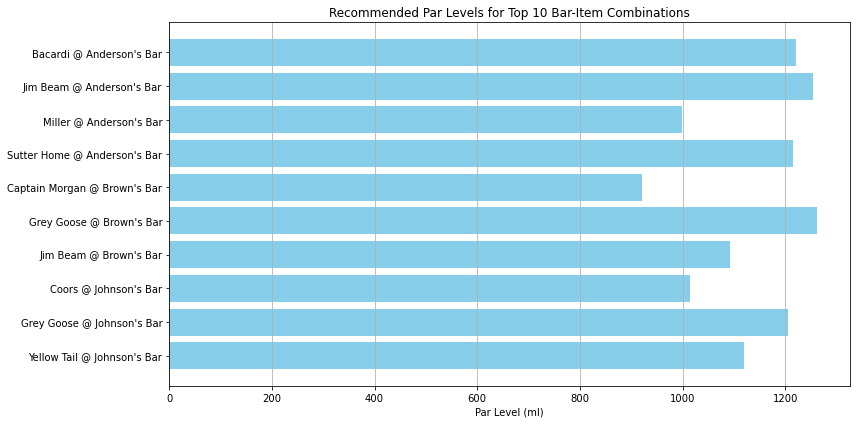

In [7]:
import matplotlib.pyplot as plt

# Show first 10 results as a table
display(rec_df.head(10))  # Jupyter-friendly table

# Plot Par Levels for top 10 by volume
top_10 = rec_df.head(10)

# Create labels for each item as "Brand @ Bar"
top_10['Label'] = top_10['Brand Name'] + ' @ ' + top_10['Bar Name']

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.barh(top_10['Label'], top_10['Par Level (ml)'], color='skyblue')
plt.xlabel('Par Level (ml)')
plt.title('Recommended Par Levels for Top 10 Bar-Item Combinations')
plt.gca().invert_yaxis()  # Highest on top
plt.grid(axis='x')
plt.tight_layout()
plt.show()


In [10]:
rec_df.to_excel("Inventory_Par_Levels.xlsx", index=False)


In [ ]:
# 📄 Final Report

##  Business Context
The hotel chain is facing operational challenges due to frequent stockouts of popular items and overstocking of slow-moving inventory across its bars. These issues lead to increased operational costs and negatively affect guest satisfaction. The goal is to forecast demand and recommend optimal inventory (par) levels to resolve these problems.

##  Solution Summary
This notebook uses historical consumption data to:
- Forecast item-level weekly demand using time series techniques.
- Recommend weekly par levels per item-bar combination using statistical logic.
- Visualize recommendations for quick decision-making.

##  Methodology
1. Preprocess data: clean and aggregate weekly consumption.
2. Analyze trends: top items, high-demand brands.
3. Forecast demand (per bar-brand pair) using time series (e.g., Exponential Smoothing).
4. Calculate par levels using:  
   **Par = Average weekly consumption + 1.5 × Standard deviation**
5. Visualize top recommendations.

##  Assumptions
- Weekly ordering frequency.
- A 1.5× buffer accounts for demand variability.
- No lead time delay is assumed.
- Forecasts are based on historical data patterns.

##  Conclusion
This system equips hotel managers with clear, data-driven insights to:
- Prevent lost sales due to stockouts.
- Minimize costs due to overstocking.
- Improve bar inventory efficiency across the hotel chain.